In [1]:
# RaceEnv -- a generic gates-and-pylons race course environment, loaded from a course definition
# (course.yaml), in meters. Modeled after PURT (Pylon Racing), but the environment itself isn't
# drone-specific -- anything that must pass through ordered gates while avoiding pylons fits here.
# Geometry (pylons, gates, bounds) is continuous and independent of the grid resolution used to
# discretize agent state: CELL_SIZE_M only controls how finely position is discretized for the Q-table.

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import yaml
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from enum import Enum

class Action(Enum):
    Right = 0
    Up = 1
    Left = 2
    Down = 3

def segment_intersection(a1, a2, b1, b2):
    # Returns (t, u) if segment (a1,a2) crosses segment (b1,b2): t is the fraction along a1->a2,
    # u is the fraction along b1->b2 where they meet. Returns None if they don't cross (or are parallel).
    a1 = np.asarray(a1, dtype=float); a2 = np.asarray(a2, dtype=float)
    b1 = np.asarray(b1, dtype=float); b2 = np.asarray(b2, dtype=float)
    d1 = a2 - a1
    d2 = b2 - b1
    denom = d1[0] * d2[1] - d1[1] * d2[0]
    if abs(denom) < 1e-9:
        return None
    diff = b1 - a1
    t = (diff[0] * d2[1] - diff[1] * d2[0]) / denom
    u = (diff[0] * d1[1] - diff[1] * d1[0]) / denom
    if 0.0 <= t <= 1.0 and 0.0 <= u <= 1.0:
        return t, u
    return None

def point_segment_distance(p, a, b):
    # Shortest distance from point p to the segment (a,b).
    p = np.asarray(p, dtype=float); a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    ab = b - a
    ab_len_sq = np.dot(ab, ab)
    if ab_len_sq < 1e-12:
        return np.linalg.norm(p - a)
    t = np.clip(np.dot(p - a, ab) / ab_len_sq, 0.0, 1.0)
    return np.linalg.norm(p - (a + t * ab))

class RaceEnv(gym.Env):
    # RaceEnv models only the physical course (movement, pylon collisions, bounds). It knows nothing
    # about gate order or rewards -- that spec lives in GateSequenceMonitor below.
    def __init__(self, course_path, CELL_SIZE_M=0.5, MAX_STEPS=400, NOISE=0, GATE_SIGMA_M=None):
        super(RaceEnv, self).__init__()

        with open(course_path) as f:
            course = yaml.safe_load(f)

        self.CELL_SIZE_M = CELL_SIZE_M
        self.MAX_STEPS = MAX_STEPS
        self.NOISE = NOISE # [0,1] -- 0: No Noise, 1: 100% Noise
        # Default the Gaussian's std-dev to the course's own safety margin, so "how far from a pylon
        # still counts as a good crossing" matches the real course spec rather than being arbitrary.
        self.GATE_MARGIN_M = course.get("gate_margin_m", 1.0)
        self.GATE_SIGMA_M = GATE_SIGMA_M if GATE_SIGMA_M is not None else self.GATE_MARGIN_M
        
        self.PYLONS = [{"xy": np.array([p["x"], p["y"]]), "r": p["r"], "name": p["name"]} for p in course["pylons"]]

        self.GATES = []
        for g in course["gates"]:
            p1 = self.PYLONS[g["p1"]]["xy"]
            p2 = self.PYLONS[g["p2"]]["xy"]
            self.GATES.append({"p1": p1, "p2": p2, "length": float(np.linalg.norm(p2 - p1)), "name": g["name"]})
        self.n_gates = len(self.GATES) # GATES[0] is also the finish, by course convention

        x_lo, x_hi = sorted((course["bounds_rect"]["min_x"], course["bounds_rect"]["max_x"]))
        y_lo, y_hi = sorted((course["bounds_rect"]["min_y"], course["bounds_rect"]["max_y"]))
        self.ORIGIN = np.array([x_lo, y_lo])
        self.GRID_NX = int(np.ceil((x_hi - x_lo) / CELL_SIZE_M)) + 1
        self.GRID_NY = int(np.ceil((y_hi - y_lo) / CELL_SIZE_M)) + 1

        # start_on_finish_cross: begin right at the finish gate's (G1's) true midpoint
        start_xy = 0.5 * (self.GATES[0]["p1"] + self.GATES[0]["p2"])
        self.INIT_STATE = self.xy_to_grid(*start_xy)

        self.observation_space = spaces.Discrete(self.GRID_NX * self.GRID_NY) # Grid index number
        self.action_space = spaces.Discrete(4) # Action space
        self.state = self.INIT_STATE
        self.n_steps = 0
        self.state_history = [self.INIT_STATE]
        self.action_history = []

    def grid_to_xy(self, index):
        col, row = index % self.GRID_NX, index // self.GRID_NX
        return self.ORIGIN + np.array([col, row]) * self.CELL_SIZE_M

    def xy_to_grid(self, x, y):
        col = int(np.clip(round((x - self.ORIGIN[0]) / self.CELL_SIZE_M), 0, self.GRID_NX - 1))
        row = int(np.clip(round((y - self.ORIGIN[1]) / self.CELL_SIZE_M), 0, self.GRID_NY - 1))
        return col + row * self.GRID_NX

    def _gate_weight(self, gate, u):
        # u is the crossing's fraction along the gate (0 at one pylon, 1 at the other); reward peaks
        # at u=0.5 (the true midpoint) and falls off the closer the crossing is to either pylon.
        sigma_t = self.GATE_SIGMA_M / gate["length"] # convert the real-meter margin into gate-fraction units
        return float(np.exp(-0.5 * ((u - 0.5) / sigma_t) ** 2))

    def reset(self):
        self.state = self.INIT_STATE
        self.n_steps = 0
        self.state_history = [self.state]
        self.action_history = []
        return self.get_observation(), self.get_info()

    def step(self, action, ignore_truncation=False):
        # Returns reward 0: rewards come from the spec monitor wrapping this env. The step's geometry
        # (movement segment, pylon hit, out-of-bounds) is reported in info so the monitor can use it.
        done = False
        truncated = False

        prev_xy = self.grid_to_xy(self.state)
        new_state = self.get_new_position(action)
        new_xy = self.grid_to_xy(new_state)

        # Collision is detected by testing the step's movement segment against each pylon's actual
        # geometry (in meters) -- exact regardless of grid resolution, no "tunneling" past a pylon.
        out_of_bounds = new_state == self.state
        hit_pylon = (not out_of_bounds) and any(point_segment_distance(p["xy"], prev_xy, new_xy) <= p["r"] for p in self.PYLONS)
        if out_of_bounds or hit_pylon:
            done = True # If the agent clips a pylon or tries to move out of bounds, end the episode

        self.state = new_state
        self.state_history.append(new_state)
        self.action_history.append(action)

        if not ignore_truncation:
            self.n_steps += 1
            truncated = self.n_steps >= self.MAX_STEPS # Truncate the episode after MAX_STEPS

        info = self.get_info()
        info.update({"prev_xy": prev_xy, "new_xy": new_xy, "hit_pylon": hit_pylon, "out_of_bounds": out_of_bounds})
        return self.get_observation(), 0, done, truncated, info

    def get_observation(self):
        return self.state

    def get_info(self):
        return {"state_history": self.state_history, "action_history": self.action_history}

    def get_new_position(self, action):
        p_dev = self.NOISE / 3.0
        tendency = np.random.choice([-1, 0, 1], p=[p_dev, 1 - 2 * p_dev, p_dev])

        transition = Action(action)
        if tendency != 0:
            match transition:
                case Action.Up:
                    transition = Action.Right if tendency == 1 else Action.Left
                case Action.Down:
                    transition = Action.Left if tendency == 1 else Action.Right
                case Action.Left:
                    transition = Action.Up if tendency == 1 else Action.Down
                case Action.Right:
                    transition = Action.Down if tendency == 1 else Action.Up

        curr_pos = self.state
        col, row = curr_pos % self.GRID_NX, curr_pos // self.GRID_NX
        match transition:
            case Action.Up:
                return curr_pos + self.GRID_NX if row < self.GRID_NY - 1 else curr_pos
            case Action.Down:
                return curr_pos - self.GRID_NX if row > 0 else curr_pos
            case Action.Left:
                return curr_pos - 1 if col > 0 else curr_pos
            case Action.Right:
                return curr_pos + 1 if col < self.GRID_NX - 1 else curr_pos

    def render(self, ax=None, title=None, legend_outside=True):
        # 1. Initialize the plot (in real meters, proportioned to the course's true aspect ratio)
        standalone = ax is None
        if standalone:
            x_span = self.GRID_NX * self.CELL_SIZE_M
            y_span = self.GRID_NY * self.CELL_SIZE_M
            fig_w = 9.0
            fig, ax = plt.subplots(figsize=(fig_w, max(4.0, fig_w * y_span / x_span)))

        x_lo, y_lo = self.ORIGIN
        x_hi = x_lo + (self.GRID_NX - 1) * self.CELL_SIZE_M
        y_hi = y_lo + (self.GRID_NY - 1) * self.CELL_SIZE_M
        pad = self.CELL_SIZE_M * 4
        ax.set_xlim(x_lo - pad, x_hi + pad)
        ax.set_ylim(y_lo - pad, y_hi + pad)
        ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5, alpha=0.6)

        # 2. Extract and Plot Gates (the full crossable edge between each pair of consecutive pylons)
        for i, gate in enumerate(self.GATES):
            ax.plot([gate["p1"][0], gate["p2"][0]], [gate["p1"][1], gate["p2"][1]], color='darkorange',
                     alpha=0.3, linewidth=6, solid_capstyle='round', zorder=0, label='Gate' if i == 0 else None)
            mid = 0.5 * (gate["p1"] + gate["p2"])
            ax.scatter(*mid, color='darkorange', marker='o', s=90, facecolors='none', edgecolors='darkorange',
                        linewidths=2, zorder=1, label='Midpoint' if i == 0 else None)

        # 3. Extract and Plot Pylons -- true collision radius (shaded disk) plus a visible center marker
        for i, pylon in enumerate(self.PYLONS):
            ax.add_patch(Circle(pylon["xy"], pylon["r"], color='firebrick', alpha=0.5, zorder=1))
            ax.scatter(*pylon["xy"], color='firebrick', marker='x', s=50, linewidths=2, zorder=2, label='Pylon' if i == 0 else None)

        # 4. Process and Plot Agent Path Line (With Smooth Continuous Gradient)
        if self.state_history:
            path_xy = np.array([self.grid_to_xy(s) for s in self.state_history])
            path_x, path_y = path_xy[:, 0], path_xy[:, 1]

            if len(path_x) > 1:
                num_interp_points = (len(path_x) - 1) * 100
                t_original = np.arange(len(path_x))
                t_fine = np.linspace(0, len(path_x) - 1, num_interp_points)
                fine_x = np.interp(t_fine, t_original, path_x)
                fine_y = np.interp(t_fine, t_original, path_y)
                points = np.array([fine_x, fine_y]).T.reshape(-1, 1, 2)
                segments = np.concatenate([points[:-1], points[1:]], axis=1)
                path_progression = np.linspace(0, 1, len(segments))

                lc = LineCollection(segments, cmap='plasma', linewidths=3, alpha=0.9, zorder=2)
                lc.set_array(path_progression)
                lc.set_clim(0, 1)
                ax.add_collection(lc)
                legend_dummy = Line2D([0], [0], color=plt.get_cmap('plasma')(0.5), lw=3, label='Agent Path')

            # Overlay directional action markers at each step along the line
            action_markers = {Action.Up.value: '^', Action.Down.value: 'v', Action.Left.value: '<', Action.Right.value: '>'}
            for i, action in enumerate(self.action_history):
                if action in action_markers:
                    ax.scatter(path_x[i], path_y[i], color='dodgerblue', marker=action_markers[action], s=60, zorder=3)

            ax.scatter(path_x[0], path_y[0], color='forestgreen', marker='s', s=120, label='Start', zorder=4)
            ax.scatter(path_x[-1], path_y[-1], color='gold', marker='*', s=250, edgecolor='black', label='Finish', zorder=4)

        # 5. Labels and Legends
        ax.set_title(title or "Race Course Visualization", fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel("X (m)")
        ax.set_ylabel("Y (m)")
        ax.set_aspect('equal')

        handles, labels = ax.get_legend_handles_labels()
        if self.state_history and len(path_x) > 1:
            handles.append(legend_dummy)
            labels.append('Agent Path')
        if legend_outside:
            ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
        else:
            ax.legend(handles, labels, loc='upper right', fontsize=8, framealpha=0.9)

        if standalone:
            plt.tight_layout()
            plt.show()

# GateSequenceMonitor -- the STL spec "cross G1..Gn in order, then return through G1, never clip a pylon,
# as fast as possible", applied as a wrapper around RaceEnv. It computes every reward.
# q (gates crossed so far) is the spec's automaton state. It can't be folded into the reward alone:
# the lap starts and ends at G1, so the same cell needs different actions at different stages of the
# lap, and a policy over position only can't express that. So q is appended to the observation,
# giving the product state [grid index, q].
class GateSequenceMonitor(gym.Wrapper):
    def __init__(self, env, REWARDS={"neutral": -1, "midpoint": 1000, "endpoint": 1000, "pylon": -1000}):
        super().__init__(env)
        self.REWARDS = REWARDS
        self.observation_space = spaces.MultiDiscrete([
            env.observation_space.n, # Grid index number
            env.n_gates + 1 # Number of gates crossed
        ])
        self.q = 0
        self.state = np.array([env.state, self.q])
        self.state_history = [self.state.copy()]
        self.reward_history = []

    def reset(self):
        pos, _ = self.env.reset()
        self.q = 0
        self.state = np.array([pos, self.q])
        self.state_history = [self.state.copy()]
        self.reward_history = []
        return self.get_observation(), self.get_info()

    def step(self, action, ignore_truncation=False):
        pos, _, done, truncated, info = self.env.step(action, ignore_truncation)
        reward = self.REWARDS["neutral"]

        if info["hit_pylon"]:
            reward += self.REWARDS["pylon"] # Penalty for clipping a pylon
        elif not info["out_of_bounds"]:
            # Only the next gate in the sequence counts; after all n gates, the finish is G1 again
            gate = self.env.GATES[self.q] if self.q < self.env.n_gates else self.env.GATES[0]
            crossing = segment_intersection(info["prev_xy"], info["new_xy"], gate["p1"], gate["p2"])
            if crossing is not None:
                _, u = crossing
                if self.q < self.env.n_gates:
                    reward += self.REWARDS["midpoint"] * self.env._gate_weight(gate, u) # Reward for crossing gates in order
                    self.q += 1 # Advance the automaton to the next gate
                else:
                    reward += self.REWARDS["endpoint"] * self.env._gate_weight(gate, u) # Reward for completing the lap
                    done = True

        self.state = np.array([pos, self.q])
        self.state_history.append(self.state.copy())
        self.reward_history.append(reward)
        return self.get_observation(), reward, done, truncated, self.get_info()

    def get_observation(self):
        return self.state

    def get_info(self):
        return {"state_history": self.state_history, "action_history": self.env.action_history, "reward_history": self.reward_history}

    def render(self, **kwargs):
        return self.env.render(**kwargs)


In [2]:
def sample_action(policy, state):
    action_probs = policy[*state] # Action probabilities (must sum to 1)
    return np.random.choice(np.size(action_probs,0), p=action_probs) # Action sampling

def run_episode(env, policy, render_result=False):
    while True:
        action = sample_action(policy, env.state)
        observation, reward, done, truncated, info = env.step(action)
        if done or truncated:
            break
    if render_result:
        env.render()
    return env.get_info()

def epsilon_greedy_action(Q, state, epsilon):
    # Choose an action epsilon-greedily with respect to Q(state, .); used by TD control,
    # which acts directly off a Q-table instead of an explicit policy array
    if np.random.random() < epsilon:
        return np.random.randint(Q.shape[-1])
    return np.argmax(Q[*state])

In [3]:
COURSE_PATH = "../../ros2_ws/src/pylon_2026_world/purt_course.yaml"
CELL_SIZE_M = 1.0              # grid resolution for discretizing agent position (1m cells) -- does NOT affect gate/pylon geometry accuracy
MAX_STEPS = 400                # generous headroom for a full lap at this grid resolution, plus room for exploration
NOISE = 0.25
REWARDS = {"neutral": -1, "midpoint": 1000, "endpoint": 1000, "pylon": -1000}
GATE_SIGMA_M = None            # None -> defaults to the course's own gate_margin_m (2.5m)
DISCOUNT_FACTOR = 0.99
ALPHA = 0.1                   # Q-Learning step size
EPSILON = 0.3                 # Q-Learning exploration rate
N_EPISODES = 10000             # Q-Learning training episodes -- kept small for demo purposes, now that the coarser 1m grid shrinks the state space

TD_EVAL_EVERY = 50            # checkpoint interval (episodes) for policy-snapshot logging

## Q-Learning Training with Reward & Policy Logging

Trains Q-Learning on the real course (loaded from `purt_course.yaml`; see the `RaceEnv` comment above), with every step's reward and every trajectory's (episode's) total reward logged for later analysis, plus the greedy policy recorded periodically throughout training so we can see how it evolves and inspect the final optimal policy.

In [4]:
def q_learning_with_logging(env, discount_factor, alpha, epsilon, n_episodes, policy_snapshot_every):
    # Initialize Q arbitrarily
    Q = np.random.random([*env.observation_space.nvec, env.action_space.n])

    step_rewards = []       # reward at every step, across all episodes, in order
    trajectory_rewards = [] # total reward per episode (trajectory)
    policy_history = []     # greedy policy (argmax Q) snapshots over the course of training

    for i in range(n_episodes):
        state, _ = env.reset()
        episode_reward = 0.0

        while True:
            # Behavior policy: epsilon-greedy with respect to Q
            action = epsilon_greedy_action(Q, state, epsilon)
            next_state, reward, done, truncated, info = env.step(action)

            # Q-Learning update -- bootstraps off max_a Q(S', a), the greedy action,
            # regardless of which action the behavior policy actually selects next
            Q[*state, action] += alpha * (reward + discount_factor * np.max(Q[*next_state]) * (1 - done) - Q[*state, action])

            step_rewards.append(reward)
            episode_reward += reward
            state = next_state
            if done or truncated:
                break

        trajectory_rewards.append(episode_reward)

        if (i + 1) % policy_snapshot_every == 0 or i == n_episodes - 1:
            policy_history.append({"episode": i + 1, "policy": np.argmax(Q, axis=-1).copy()})

    return Q, step_rewards, trajectory_rewards, policy_history

In [5]:
env_ql = GateSequenceMonitor(RaceEnv(COURSE_PATH, CELL_SIZE_M=CELL_SIZE_M, MAX_STEPS=MAX_STEPS, NOISE=NOISE, GATE_SIGMA_M=GATE_SIGMA_M), REWARDS)
Q, step_rewards, trajectory_rewards, policy_history = q_learning_with_logging(
    env_ql, DISCOUNT_FACTOR, ALPHA, EPSILON, N_EPISODES, TD_EVAL_EVERY
)
final_policy = policy_history[-1]["policy"]

print(f"Grid: {env_ql.unwrapped.GRID_NX} x {env_ql.unwrapped.GRID_NY} cells ({env_ql.unwrapped.CELL_SIZE_M}m each), {env_ql.unwrapped.n_gates} gates")
print(f"Logged {len(step_rewards)} steps across {len(trajectory_rewards)} trajectories")
print(f"Captured {len(policy_history)} policy snapshots (every {TD_EVAL_EVERY} episodes)")
print(f"Laps completed (reached the finish before truncating): {sum(1 for r in trajectory_rewards if r > REWARDS['midpoint'] * env_ql.unwrapped.n_gates)}/{len(trajectory_rewards)}")

Grid: 38 x 29 cells (1.0m each), 4 gates
Logged 1221999 steps across 10000 trajectories
Captured 200 policy snapshots (every 50 episodes)
Laps completed (reached the finish before truncating): 6795/10000


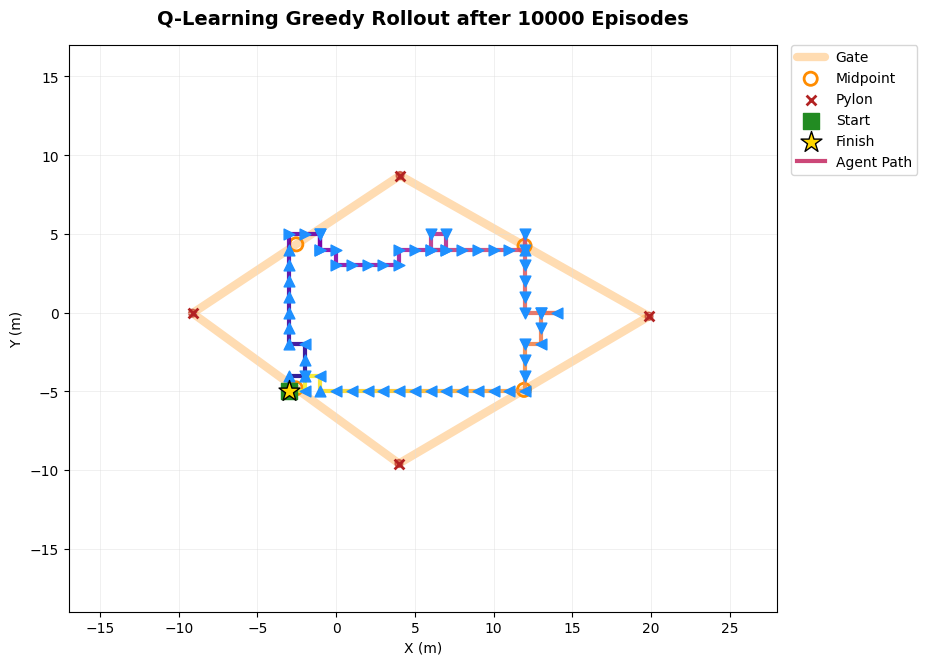

In [6]:
# Sanity check: roll out the final greedy policy and render the path it takes
final_policy_probs = np.eye(env_ql.action_space.n)[final_policy]
env_ql.reset()
run_episode(env_ql, final_policy_probs)
env_ql.render(title=f"Q-Learning Greedy Rollout after {N_EPISODES} Episodes")
